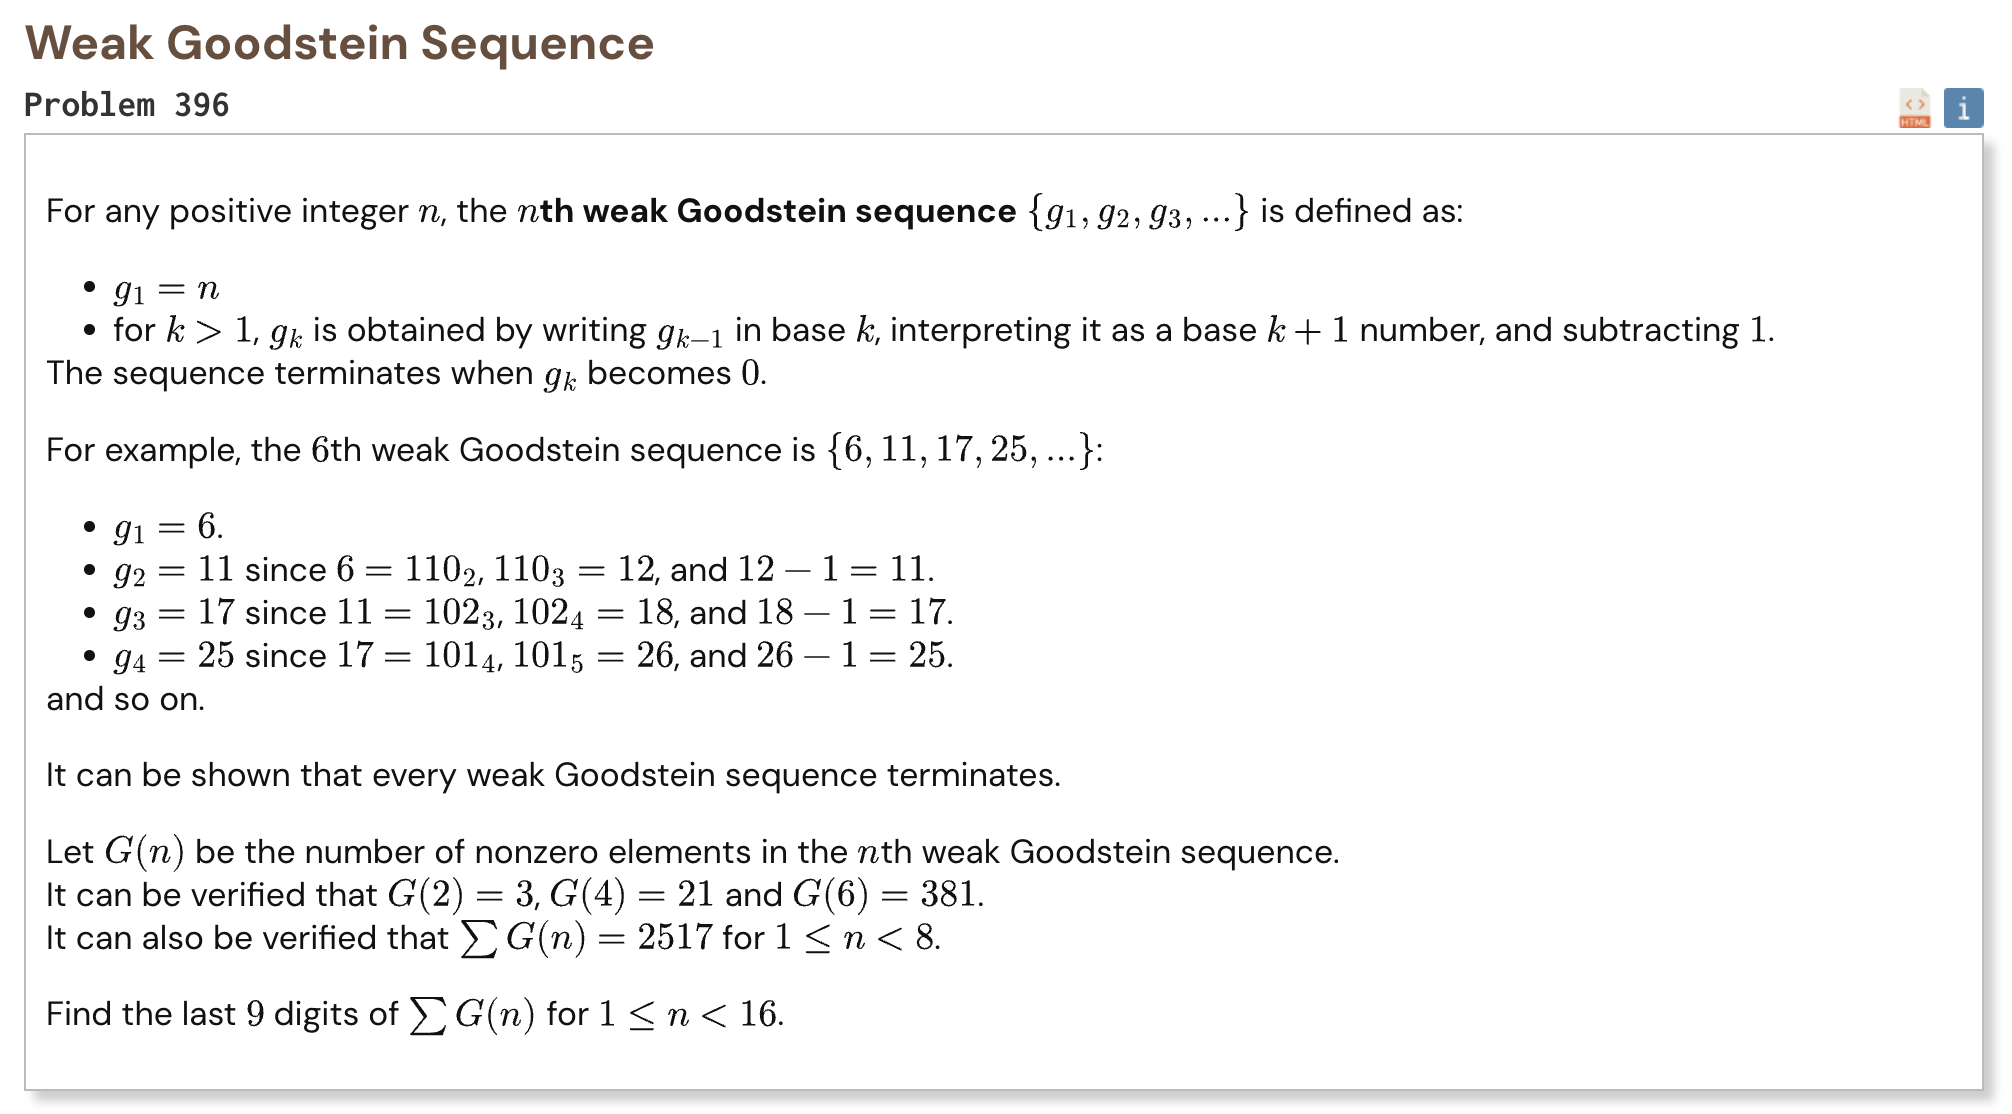

## Initial approach

-   replace the changing base in the sequence with an ordinal style representation
-   the binary digits of n describe which Hardy hierarchy functions must be applied
-   the sequence length is the final base reached minus two
-   for values below eight the result can be calculated exactly with simple closed formulas
-   values from eight to fifteen require repeated use of f of x equals x plus one times two to the power x plus one minus one
-   the numbers become far too large to store directly so calculate only modulo one billion
-   split the modulus into 512 and 1953125 and combine the two results with the Chinese remainder theorem
-   add all values from 1 to 15 and keep only the last nine digits

In [1]:
MOD = 10 ** 9
MOD2 = 2 ** 9
MOD5 = 5 ** 9


def extended_gcd(a, b):
    x0, y0, x1, y1 = 1, 0, 0, 1

    while b:
        quotient = a // b
        a, b = b, a - quotient * b
        x0, x1 = x1, x0 - quotient * x1
        y0, y1 = y1, y0 - quotient * y1

    return a, x0, y0


def inverse_mod(a, modulus):
    return extended_gcd(a % modulus, modulus)[1] % modulus


def factor_two_five(value):
    power_two = 0
    power_five = 0

    while value % 2 == 0:
        value //= 2
        power_two += 1

    while value % 5 == 0:
        value //= 5
        power_five += 1

    return power_two, power_five


def phi(value):
    if value == 1:
        return 1

    power_two, power_five = factor_two_five(value)

    part_two = 1 if power_two <= 1 else 2 ** (power_two - 1)
    part_five = 1 if power_five == 0 else 4 * 5 ** (power_five - 1)

    return part_two * part_five


def phi_chain(modulus):
    values = [modulus]

    while values[-1] != 1:
        values.append(phi(values[-1]))

    return values


def hardy_omega_squared(x):
    return (x + 1) * 2 ** (x + 1) - 1


def exact_final_base(n):
    value = 2 + (n & 1)

    if n & 2:
        value = 2 * value + 1

    if n & 4:
        value = hardy_omega_squared(value)

    return value


MOD5_CHAIN = phi_chain(MOD5)


def iterate_mod_five(x, repetitions):
    residues = [x % modulus for modulus in MOD5_CHAIN]

    for _ in range(repetitions):
        next_residues = [0] * len(MOD5_CHAIN)

        for index, modulus in enumerate(MOD5_CHAIN[:-1]):
            exponent = (residues[index + 1] + 1) % phi(modulus)

            next_residues[index] = (
                (residues[index] + 1)
                * pow(2, exponent, modulus)
                - 1
            ) % modulus

        residues = next_residues

    return residues[0]


def iterate_mod_two(x, repetitions):
    residue = x % MOD2
    exact_value = x if x <= 20 else None

    for _ in range(repetitions):
        if exact_value is not None and exact_value + 1 < 9:
            power = 2 ** (exact_value + 1)
            next_value = hardy_omega_squared(exact_value)
            exact_value = next_value if next_value <= 20 else None
        else:
            power = 0
            exact_value = None

        residue = ((residue + 1) * power - 1) % MOD2

    return residue


CRT_INVERSE = inverse_mod(MOD2, MOD5)


def combine_residues(residue_two, residue_five):
    multiplier = (
        (residue_five - residue_two)
        * CRT_INVERSE
    ) % MOD5

    return (residue_two + MOD2 * multiplier) % MOD


def solve():
    final_bases = [exact_final_base(n) for n in range(8)]

    assert final_bases[2] - 2 == 3
    assert final_bases[4] - 2 == 21
    assert final_bases[6] - 2 == 381

    assert sum(
        final_bases[n] - 2
        for n in range(1, 8)
    ) == 2517

    for n in range(8, 16):
        starting_value = final_bases[n - 8]
        repetitions = starting_value + 1

        residue_two = iterate_mod_two(
            starting_value,
            repetitions
        )

        residue_five = iterate_mod_five(
            starting_value,
            repetitions
        )

        final_bases.append(
            combine_residues(
                residue_two,
                residue_five
            )
        )

    return sum(
        final_bases[n] - 2
        for n in range(1, 16)
    ) % MOD

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 173214653
CPU times: user 58.5 ms, sys: 1.7 ms, total: 60.2 ms
Wall time: 59.3 ms
